In [ ]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000") #
mlflow.set_experiment("tax-trail-experiment")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1788628814807, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788628814807, lifecycle_stage='active', name='tax-trail-experiment', tags={}, trace_location=None, workspace='default'>

In [2]:
!python -V

Python 3.14.6


In [2]:
import pandas as pd

In [3]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import pickle

In [6]:
df = pd.read_parquet('./data/green_tripdata_2026-01.parquet')
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td : td.total_seconds()/60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
df[categorical] = df[categorical].astype(str)

In [7]:
train_dicts = df[categorical + numerical].to_dict(orient='records')
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_train)
root_mean_squared_error(y_train, y_pred)

8.048598407031138

/tmp/ipykernel_95720/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_95720/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


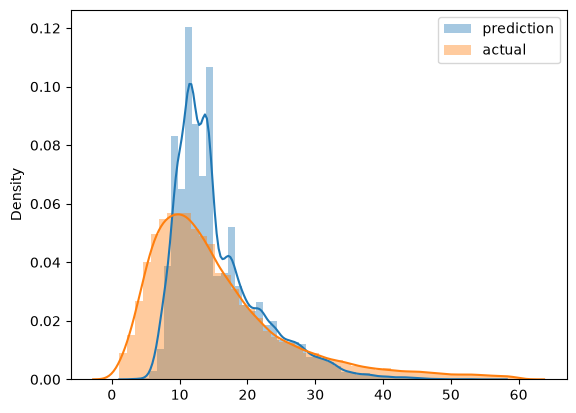

In [17]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [18]:

def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df


In [19]:
df_train = read_dataframe('./data/green_tripdata_2026-01.parquet')
df_val =  read_dataframe('./data/green_tripdata_2026-02.parquet')


In [20]:
len(df_train), len(df_val)

(38088, 35319)

In [21]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [22]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)


In [23]:

target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.108776436930401

In [25]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [18]:
with mlflow.start_run():
    alpha = 0.001
    mlflow.set_tag("developer","vamsi")
    mlflow.log_param("train-data-path","./data/green_tripdata_2026-01.parquet")
    mlflow.log_param("validation-data-path","./data/green_tripdata_2026-02.parquet")

    lr = Lasso(alpha)
    mlflow.log_param("hyperparameter",alpha)
    X_train = X_train.astype("int32")
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse",rmse)
    mlflow.log_artifact(local_path='models/lin_reg.bin',artifact_path='model_pickle')

🏃 View run indecisive-mink-924 at: http://localhost:5000/#/experiments/1/runs/e31c9ba19ab54f4d986375d78d9f7969
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [24]:




mlflow.end_run()

🏃 View run skillful-bug-528 at: http://localhost:5000/#/experiments/1/runs/17bfbd49da884e4db5f90cdbcf2a4df3
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [27]:
import xgboost as xgb
import mlflow

from sklearn.metrics import root_mean_squared_error

# Convert data into XGBoost DMatrix
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

# Best hyperparameters obtained from Hyperopt
best_params = {
    "learning_rate": 0.19001418396691874,
    "max_depth": 69,
    "min_child_weight": 2.4282401046168354,
    "objective": "reg:squarederror",
    "reg_alpha": 0.007145230476103732,
    "reg_lambda": 0.10855350873819329,
    "seed": 42
}

# Start a new MLflow run
with mlflow.start_run():

    # Log hyperparameters
    mlflow.log_params(best_params)

    # Train XGBoost model
    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=100,
        evals=[(valid, "validation")],
        early_stopping_rounds=50
    )

    # Make predictions
    y_pred = booster.predict(valid)

    # Calculate validation RMSE
    rmse = root_mean_squared_error(y_val, y_pred)

    # Log RMSE
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b","wb") as f_out:
        pickle.dump(dv, f_out)
    
    mlflow.log_artifact("models/preprocessor.b",artifact_path ="proprocessor")

    # Log model to MLflow
    mlflow.xgboost.log_model(booster,artifact_path="model_mlflow")

    print(f"Validation RMSE: {rmse}")

[0]	validation-rmse:9.13425
[1]	validation-rmse:8.21961
[2]	validation-rmse:7.55830
[3]	validation-rmse:7.08881
[4]	validation-rmse:6.76286
[5]	validation-rmse:6.53998
[6]	validation-rmse:6.38729
[7]	validation-rmse:6.28468
[8]	validation-rmse:6.21356
[9]	validation-rmse:6.16633
[10]	validation-rmse:6.13572
[11]	validation-rmse:6.11392
[12]	validation-rmse:6.10042
[13]	validation-rmse:6.08857
[14]	validation-rmse:6.08055
[15]	validation-rmse:6.07480
[16]	validation-rmse:6.07272
[17]	validation-rmse:6.06831
[18]	validation-rmse:6.06355
[19]	validation-rmse:6.06082
[20]	validation-rmse:6.05991
[21]	validation-rmse:6.05681
[22]	validation-rmse:6.05522
[23]	validation-rmse:6.05367
[24]	validation-rmse:6.05320
[25]	validation-rmse:6.05265
[26]	validation-rmse:6.05315
[27]	validation-rmse:6.05309
[28]	validation-rmse:6.05414
[29]	validation-rmse:6.05435
[30]	validation-rmse:6.05381
[31]	validation-rmse:6.05399
[32]	validation-rmse:6.05325
[33]	validation-rmse:6.05370
[34]	validation-rmse:6.0

2026/09/07 15:30:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Validation RMSE: 6.065011682696606
🏃 View run abundant-jay-613 at: http://localhost:5000/#/experiments/1/runs/fe01d914aa47450490158ed71c606b59
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [32]:
logged_model = 'runs:/fe01d914aa47450490158ed71c606b59/model_mlflow'
loaded_model = mlflow.pyfunc.load_model(logged_model)

In [33]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: mlflow-artifacts:/1/models/m-30f3d57d33714497b5de4a4ea999839b/artifacts
  flavor: mlflow.xgboost
  run_id: fe01d914aa47450490158ed71c606b59

In [35]:
xgboost_model = mlflow.xgboost.load_model(logged_model)

In [37]:
y_pred = xgboost_model.predict(valid)


In [38]:
y_pred[:10]

array([ 4.7622247,  7.7987046, 25.700619 , 20.56971  , 17.290873 ,
        8.2932   , 29.92936  , 23.290852 , 11.849863 ,  3.243107 ],
      dtype=float32)

In [39]:
xgboost_model